In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance


In [33]:
def wrangle(filepath):
    #read csv into DataFrame
    df = pd.read_csv(filepath)

    # =====================================================
    
    # Merge Patient Admission Date and Patient Admission Time column
    df["Admission DateTime"] = pd.to_datetime(
        df["Patient Admission Date"] + " " + df["Patient Admission Time"], dayfirst=True
    )

    # Drop columns with more than 40% null values, merged, and irrelvant 
    df.drop(columns=(["Department Referral",
                      "Patient Satisfaction Score", 
                      "Patient Admission Date",
                      "Patient Admission Time", 
                      "Patient Id", 
                      "Merged"]),
            inplace=True)

    # =====================================================
    
    # Set Admission DateTime column as index
    df.set_index("Admission DateTime", inplace=True)

    # Sort index
    df.sort_index(inplace=True)

    # =====================================================
    # Create Weekday / Weekend Feature

    df["Day Type"] = np.where(
        df.index.dayofweek < 5,
        "Weekday",
        "Weekend"
    )

    # Make ordered categorical
    df["Day Type"] = pd.Categorical(
        df["Day Type"],
        categories=["Weekday", "Weekend"],
        ordered=True
    )

     # Create column with month name
    df.insert(0, "Admission Month", df.index.month_name() )

    # Create Ordered Days in Visualization
    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    df["Admission Month"] = pd.Categorical(
        df["Admission Month"],
        categories = month_order,
        ordered = True
    )

    # =====================================================
    # Create Shift Duty Column
    shift_hour = df.index.hour

    shift_conditions = [
        (shift_hour >= 6) & (shift_hour < 14),   # 06:00–13:59
        (shift_hour >= 14) & (shift_hour < 21), # 14:00–20:59
        (shift_hour >= 21) | (shift_hour < 6)   # 21:00–05:59
    ]

    shift_labels = [
        "Morning",
        "Afternoon",
        "Night"
    ]

    shift_duty = np.select(
        shift_conditions,
        shift_labels,
        default="Unknown"
    )

    # Insert as FIRST column
    df.insert(0, "Shift Duty", shift_duty)

    # Make Shift Duty ordered
    df["Shift Duty"] = pd.Categorical(
        df["Shift Duty"],
        categories=["Morning", "Afternoon", "Night"],
        ordered=True
    )
    # =====================================================
    # Create Grouped Waittime
    waittime_bins = [0, 15, 30, 60, np.inf]

    waittime_labels = [
        "0–15 mins",
        "16–30 mins",
        "31–60 mins",
        "60+ mins"
    ]

    df["Grouped Waittime"] = pd.cut(
        df["Patient Waittime"],
        bins=waittime_bins,
        labels=waittime_labels,
        right=True,
        include_lowest=True
    )

    # Make Grouped Waittime ordered
    df["Grouped Waittime"] = pd.Categorical(
        df["Grouped Waittime"],
        categories=waittime_labels,
        ordered=True
    )

    
    # =====================================================
    # Create Age Groups
    bins = [0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80]

    labels = [
        "Under Five",
        "School Age Child",
        "Early Adolescent",
        "Late Adolescent",
        "Young Adult",
        "Early Adult",
        "Midlife Adult",
        "Late Adult",
        "Young Elderly",
        "Older Elderly"
    ]

    df["Age Group"] = pd.cut(
        df["Patient Age"],
        bins=bins,
        labels=labels,
        right=False
    )

    # Make Age Group Chronological
    df["Age Group"] = pd.Categorical(
        df["Age Group"],
        categories=labels,
        ordered=True
    )

    # Higher-level category mapping
    age_category_map = {
        "Under Five": "Child",
        "School Age Child": "Child",

        "Early Adolescent": "Adolescent",
        "Late Adolescent": "Adolescent",

        "Young Adult": "Adult",
        "Early Adult": "Adult",
        "Midlife Adult": "Adult",
        "Late Adult": "Adult",

        "Young Elderly": "Elderly",
        "Older Elderly": "Elderly"
    }

    df["Age Category"] = df["Age Group"].map(age_category_map)

    # Make the Age Category ordered
    category_order = [
        "Child",
        "Adolescent",
        "Adult",
        "Elderly"
    ]
    
    df["Age Category"] = pd.Categorical(
        df["Age Category"],
        categories=category_order,
        ordered=True
    )

    # Color Mapping
    age_color_map = {
        "Child": "yellow",
        "Adolescent": "red",
        "Adult": "blue",
        "Elderly": "gray"
    }
    
    df["Age Color"] = df["Age Category"].map(age_color_map)

    # Drop  unnecessary columns
    df.drop(columns=["Patient Waittime", "Grouped Waittime", "Age Color"], inplace=True)

    df["Patient Admission Flag"] = df["Patient Admission Flag"].map({"Not Admission": 0, "Admission": 1})

    return df

def coefficient_of_variation(series):
    return(series.std()/series.mean()) * 100

In [34]:
df = wrangle("../data/healthcare_analytics_patient_flow_data.csv")
df.head(2)

,Shift Duty,Admission Month,Patient Gender,Patient Age,Patient Race,Patient Admission Flag,Day Type,Age Group,Age Category
Admission DateTime,,,,,,,,,
2023-04-01 01:13:00,Night,April,Male,60,Two or More Races,1,Weekend,Young Elderly,Elderly
2023-04-01 01:21:00,Night,April,Male,18,Two or More Races,1,Weekend,Late Adolescent,Adolescent


In [20]:
print(df["Patient Admission Flag"].unique())
print(df["Patient Admission Flag"].dtype)
print(df["Patient Admission Flag"].isnull().sum())

[1 0]
int64
0


In [21]:
df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 9216 entries, 2023-04-01 01:13:00 to 2024-10-30 23:44:00
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Shift Duty              9216 non-null   category
 1   Admission Month         9216 non-null   category
 2   Patient Gender          9216 non-null   str     
 3   Patient Age             9216 non-null   int64   
 4   Patient Race            9216 non-null   str     
 5   Patient Admission Flag  9216 non-null   int64   
 6   Day Type                9216 non-null   category
 7   Age Group               9216 non-null   category
 8   Age Category            9216 non-null   category
dtypes: category(5), int64(2), str(2)
memory usage: 406.2 KB


In [22]:
print(df["Patient Admission Flag"].unique())
print(df["Patient Admission Flag"].dtype)

[1 0]
int64


In [23]:
target = "Patient Admission Flag"
X = df.drop(columns=["Patient Admission Flag"])
y = df[target]

len(X)

9216

In [24]:
print(df["Patient Admission Flag"].unique())

[1 0]


In [25]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)  

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train) 

In [26]:
# Column Transformer for encoding categorical variables
cat_features = X.select_dtypes(include=["category", "object","string"]).columns

column_transformer = ColumnTransformer(
    transformers=[
        ("onehotencoder", OneHotEncoder(drop="first"), cat_features)
    ],
    remainder="passthrough"
)

# Build XGBoost model pipeline

model = make_pipeline(
    column_transformer,
    XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )
)

# Fit the model

model.fit(X_train, y_train)

c:\Users\HP\OneDrive\Desktop\healthcare-patient-flow-analysis\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:33:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('xgbclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [27]:
# Predict on validation set

y_val_pred = model.predict(X_val)

accuracy_score(y_val, y_val_pred)

0.5051546391752577

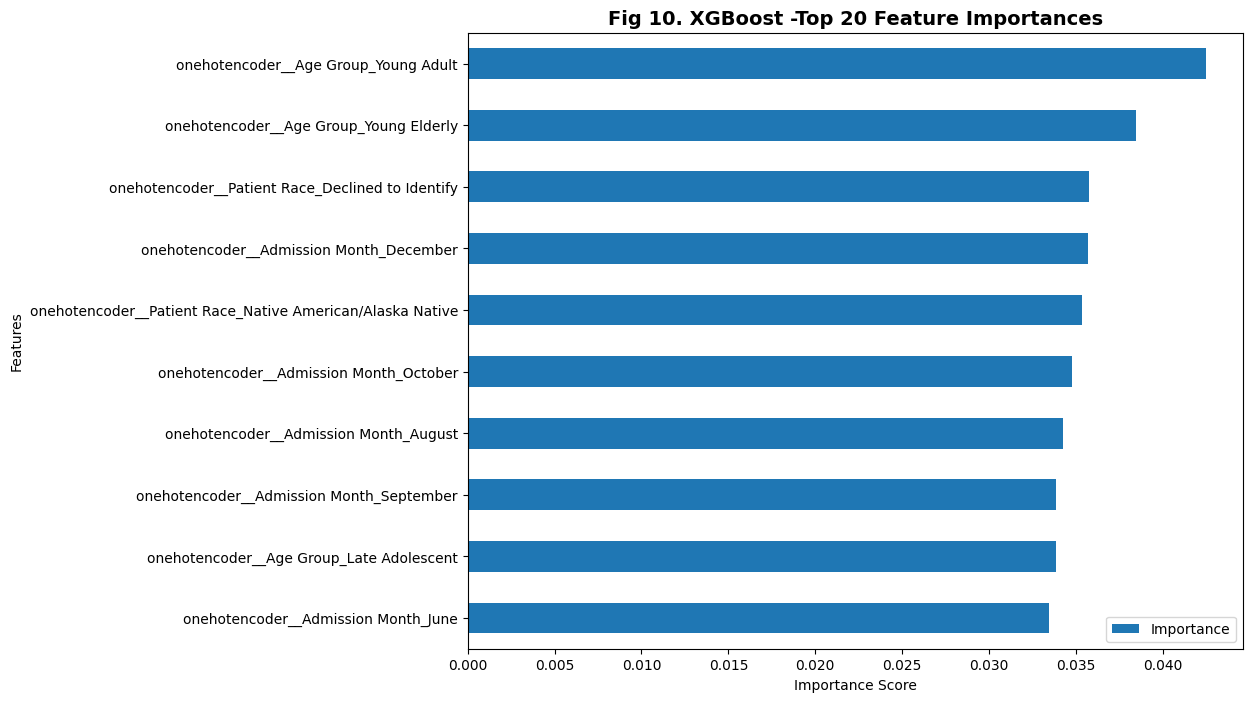

In [39]:
# Plot importance from XGBoost model

xgb_model = model.named_steps["xgbclassifier"]

# Get feature names from column transformer
feature_names = model.named_steps["columntransformer"].get_feature_names_out()

# Extract feature importance from XGBoost model
importance = xgb_model.feature_importances_

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)    


importance_df.head(10).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(10,8)
)

plt.gca().invert_yaxis()
plt.title("Fig 10. XGBoost -Top 20 Feature Importances", weight="bold", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()